In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Load our pizza data
df = pd.read_csv('pizza_orders.csv')
df['revenue'] = df['price'] * df['quantity']

# Set the style — you already did this in your original notebook!
sns.set_style('darkgrid')

print("Seaborn version:", sns.__version__)
print("Ready!")

Seaborn version: 0.13.2
Ready!


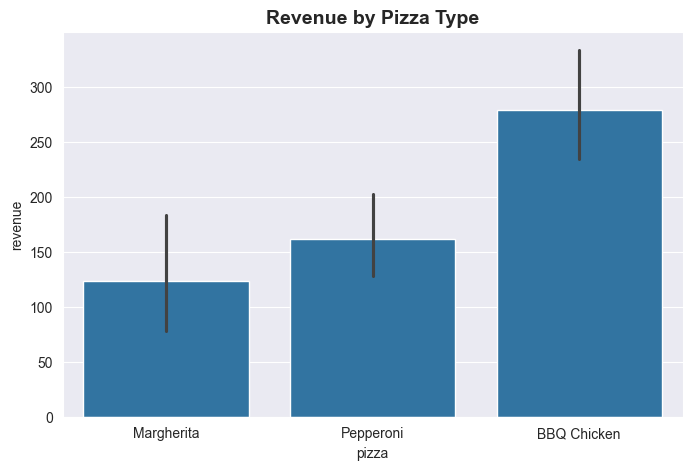

In [2]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(data=df, x='pizza', y='revenue', ax=ax)

ax.set_title('Revenue by Pizza Type', fontsize=14, fontweight='bold')
plt.show()

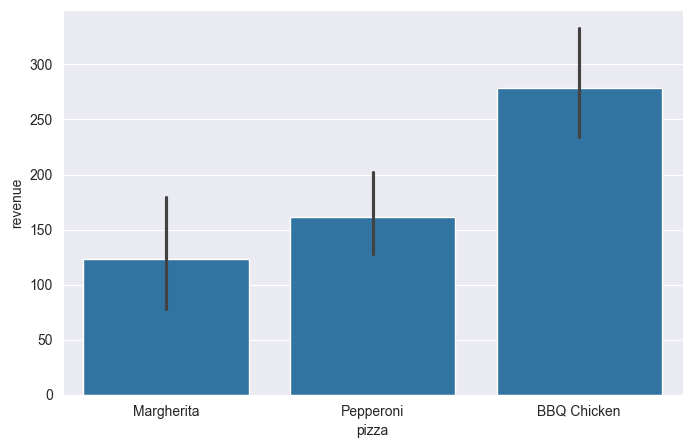

In [3]:
# Version 1 — explicit Matplotlib canvas
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=df, x='pizza', y='revenue', ax=ax)
plt.show()

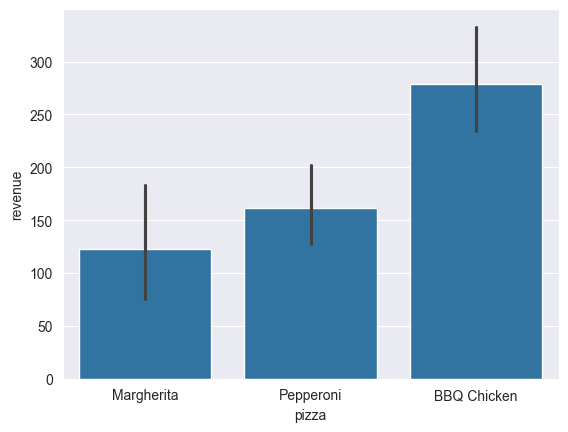

In [4]:
# Version 2 — Seaborn creates canvas automatically
sns.barplot(data=df, x='pizza', y='revenue')
plt.show()

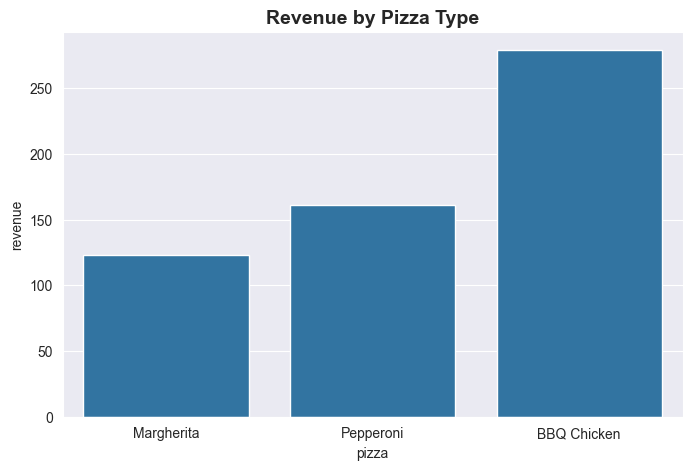

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

# sns.barplot(data=df, x='pizza', y='revenue', ax=ax)
# Remove error bars
sns.barplot(data=df, x='pizza', y='revenue', errorbar=None)

ax.set_title('Revenue by Pizza Type', fontsize=14, fontweight='bold')
plt.show()

Show revenue by pizza type — but also split by area (Downtown vs Suburbs)

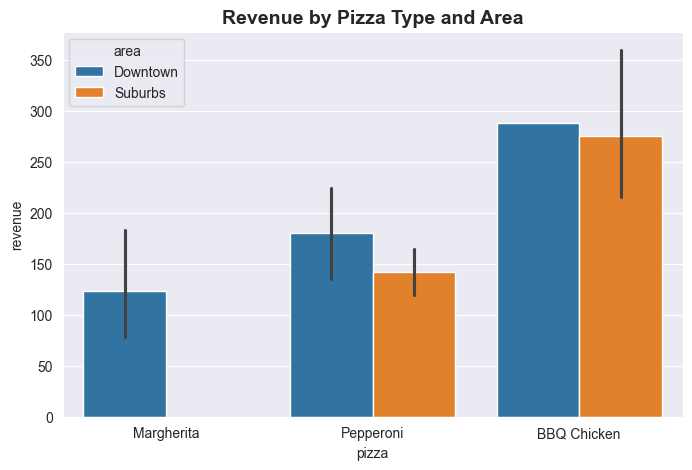

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(data=df, x='pizza', y='revenue', hue='area', ax=ax)

ax.set_title('Revenue by Pizza Type and Area', fontsize=14, fontweight='bold')
plt.show()

boxplot

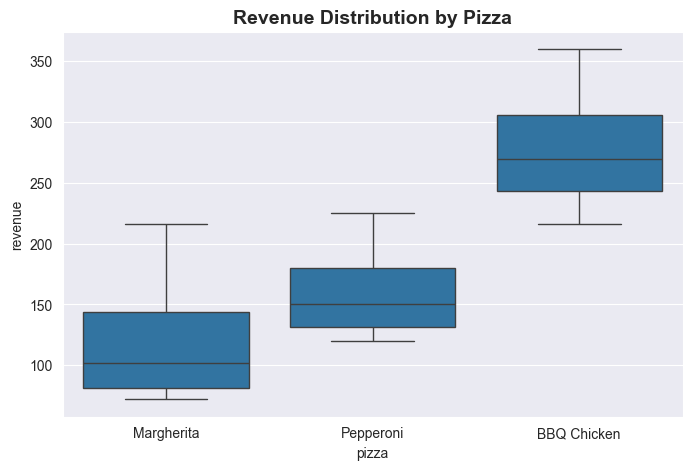

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(data=df, x='pizza', y='revenue', ax=ax)

ax.set_title('Revenue Distribution by Pizza', fontsize=14, fontweight='bold')
plt.show()

Show me revenue for every pizza type on every day in one single view

In [9]:
# Create a pivot table — pizza types as columns, days as rows
day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

pivot = df.pivot_table(values='revenue', 
                       index='date', 
                       columns='pizza',
                       aggfunc='sum').reindex(day_order)

print(pivot)

pizza  BBQ Chicken  Margherita  Pepperoni
date                                     
Mon            NaN       120.0      135.0
Tue          252.0         NaN      120.0
Wed            NaN       156.0        NaN
Thu          216.0         NaN      165.0
Fri          288.0         NaN      225.0
Sat          360.0         NaN        NaN
Sun            NaN       216.0        NaN


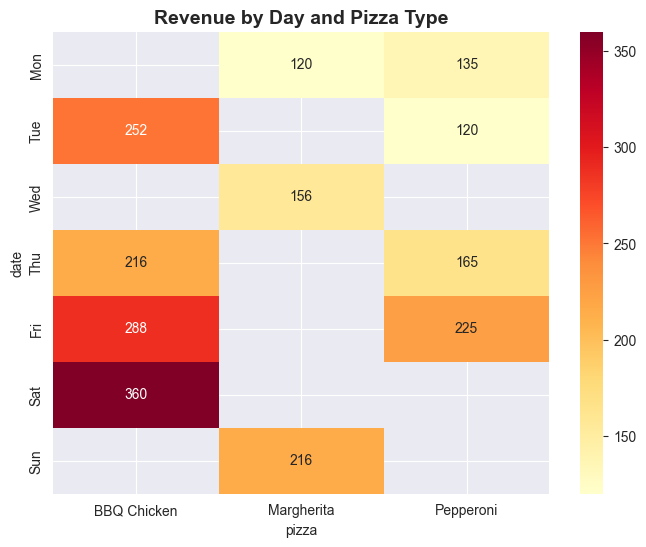

In [17]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(pivot, 
            annot=True,        # show numbers inside cells
            fmt='g',           # clean number format
            cmap='YlOrRd',     # color scheme
            ax=ax)

ax.set_title('Revenue by Day and Pizza Type', fontsize=14, fontweight='bold')
plt.show()

 Build a complete dashboard:

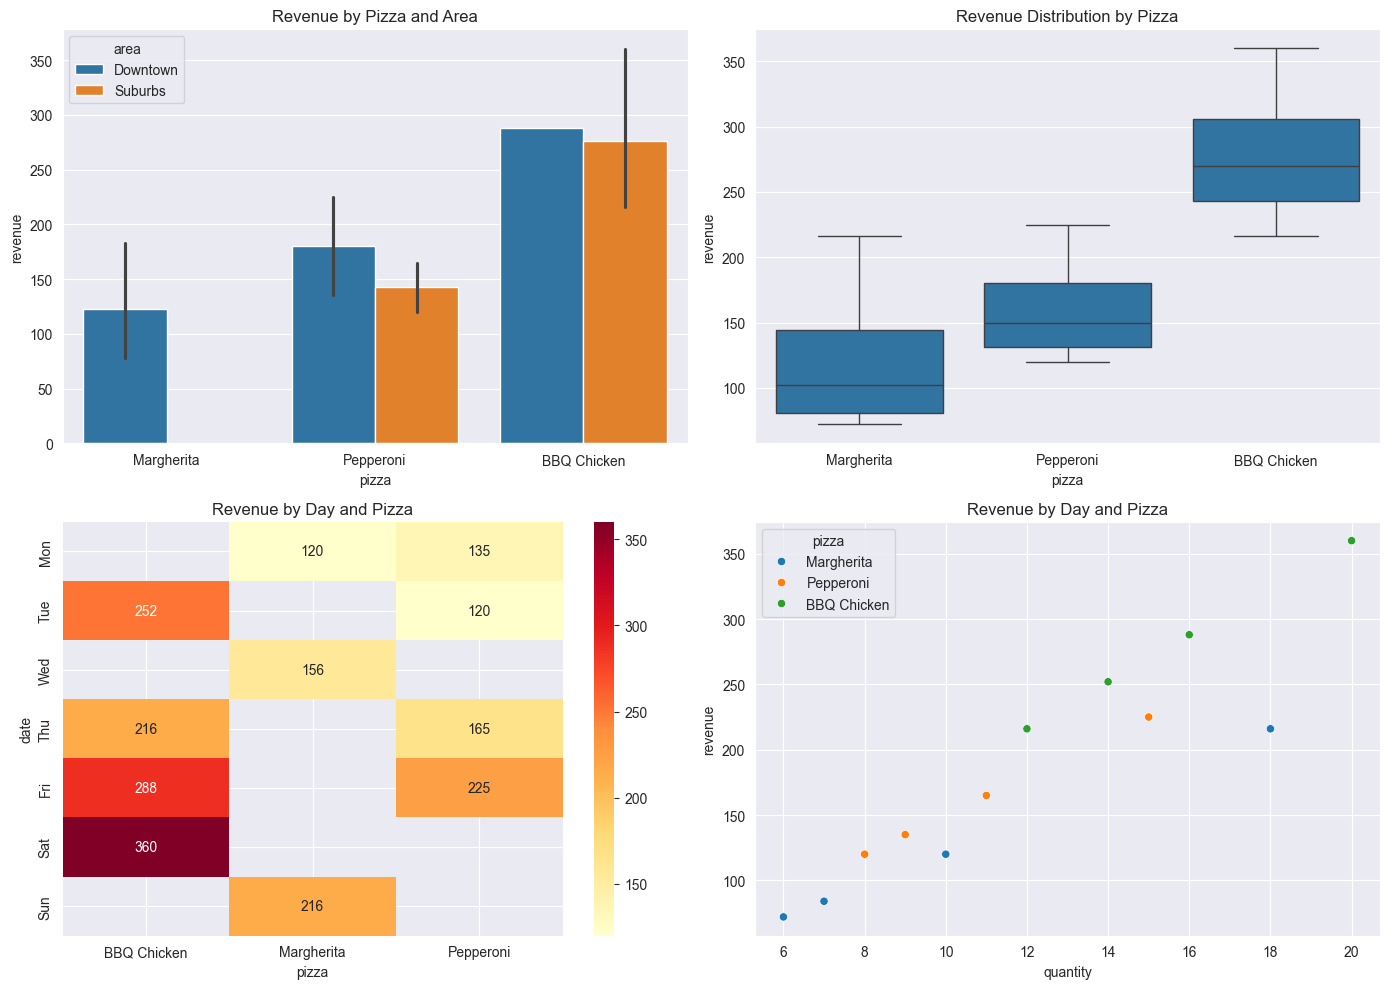

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Chart 1 — top left — Bar chart with hue
sns.barplot(data=df, x='pizza', y='revenue', 
            hue='area', ax=axes[0,0])
axes[0,0].set_title('Revenue by Pizza and Area')

# Chart 2 — top right — Box plot
sns.boxplot(data=df, x='pizza', y='revenue', ax=axes[0,1])
axes[0,1].set_title('Revenue Distribution by Pizza')

# Chart 3 — bottom left — Heatmap
sns.heatmap(pivot, annot=True, fmt='g', 
            cmap='YlOrRd', ax=axes[1,0])
axes[1,0].set_title('Revenue by Day and Pizza')

# Chart 4 — bottom right — your turn!
# Write a scatter plot of quantity vs revenue
# colored by pizza type using hue
# YOUR CODE HERE
sns.scatterplot(data=df, x='quantity', y='revenue', hue="pizza",ax=axes[1,1])
axes[1,1].set_title('Revenue by Day and Pizza')

plt.tight_layout()
plt.show()

In [23]:
fig.savefig('pizza_final_dashboard.png', dpi=150, bbox_inches='tight')